# Phase 1 — Setup
Install packages, import all libraries, define global config and hyperparameters, verify the environment.

In [2]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-cache-dir", *args])

# 1. Force the foundation
pip("numpy==1.26.4", "--force-reinstall")
pip("monai==1.4.0", "einops", "nibabel", "xgboost", "joblib", "SimpleITK")

# 2. Install PyRadiomics from the master branch (bypassing the broken PyPI metadata)
# We use --no-build-isolation to use the numpy we just installed
try:
    print("Attempting to install patched PyRadiomics from GitHub...")
    pip("git+https://github.com/Radiomics/pyradiomics.git@master")
except:
    print("GitHub install failed. Proceeding WITHOUT radiomics.")
    print("You will need to comment out Phase 4D to run the rest of the notebook.")

print("\n--- INSTALLATION FINISHED ---")
print("RESTART KERNEL NOW.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 55.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 170.8 kB/s eta 0:00:00
Attempting to install patched PyRadiomics from GitHub...
  Cloning https://github.com/Radiomics/pyradiomics.git (to revision master) to /tmp/pip-req-build-364b_oy6


  Running command git clone --filter=blob:none --quiet https://github.com/Radiomics/pyradiomics.git /tmp/pip-req-build-364b_oy6


  Resolved https://github.com/Radiomics/pyradiomics.git to commit 8ed579383b44806651c463d5e691f3b2b57522ab
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 291.5 MB/s eta 0:00:00
  Created wheel for pyradiomics: filename=pyradiomics-3.1.1.dev111+g8ed579383-cp312-cp312-linux_x86_64.whl size=121728 sha256=55e9327459b3407258823a7f5f743261a6dd61c79a13e56c45e71e14a0a7577c
  Stored in directory: /tmp/pip-ephem-wheel-cache-b85pgrgs/wheels/c2/e8/8c/696ca4596

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
monai 1.4.0 requires numpy<2.0,>=1.24, but you have numpy 2.4.4 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.



--- INSTALLATION FINISHED ---
RESTART KERNEL NOW.


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, gc, json, pickle, warnings, logging, time
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

import nibabel as nib
import SimpleITK as sitk

import monai
from monai.data import Dataset, CacheDataset, DataLoader
from monai.inferers import sliding_window_inference
from monai.losses import DiceCELoss, DiceFocalLoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.networks.nets import SwinUNETR
from monai.transforms import (
    AsDiscrete, Activations, Compose,
    ConvertToMultiChannelBasedOnBratsClassesd,
    CropForegroundd, EnsureChannelFirstd, EnsureTyped,
    LoadImaged, NormalizeIntensityd, Orientationd,
    RandFlipd, RandRotate90d, RandScaleIntensityd,
    RandShiftIntensityd, RandSpatialCropd, Spacingd,
)
from monai.utils.enums import MetricReduction

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from xgboost import XGBClassifier
from radiomics import featureextractor

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

# ── Hyperparameters and Config ────────────────────────────────────────────────
# All tuneable values live here. Nothing is hardcoded elsewhere.
#
# Memory budget: T4 x2 → 2 × 15 GB VRAM = 30 GB GPU, 29 GB RAM
#   feature_size=24  → ~15 M params vs 62 M for size=48; fits both GPUs easily
#   batch_size=2     → 1 sample per GPU (DataParallel split)
#   sw_batch_size=2  → sliding-window inference, 2 windows in parallel per GPU
#   No CacheDataset  → avoids ~23 GB RAM overhead (BraTS 240³ × n_subjects)
#   tta_n=5          → 5 TTA passes; keeps uncertainty peak RAM under 4 GB
#   max_epochs=50    → conservative for 12-h Kaggle session; increase if resuming

@dataclass
class Config:
    # ── Paths ─────────────────────────────────────────────────────────────────
    data_root  : str   = "/kaggle/input/datasets/dschettler8845/brats-2021-task1"
    output_dir : str   = "/kaggle/working/outputs"
    mgmt_csv   : str   = "/kaggle/input/brats2021task1/MGMT_labels.csv"

    # ── Data splits ───────────────────────────────────────────────────────────
    val_frac   : float = 0.15
    test_frac  : float = 0.10
    split_seed : int   = 42

    # ── Preprocessing ─────────────────────────────────────────────────────────
    pixdim   : Tuple  = (1.0, 1.0, 1.0)   # isotropic 1 mm³
    roi_size : Tuple  = (128, 128, 128)    # patch size for training + sliding window

    # ── Model ─────────────────────────────────────────────────────────────────
    in_channels   : int  = 4      # T1, T1ce, T2, FLAIR
    out_channels  : int  = 3      # TC, WT, ET
    feature_size  : int  = 24     # 24 → ~15 M params; memory-safe on T4 x2
    use_checkpoint: bool = True   # gradient checkpointing saves ~40% VRAM

    # ── Training ──────────────────────────────────────────────────────────────
    batch_size    : int   = 2     # 1 sample per GPU
    loss_type     : str   = "dice_ce"
    learning_rate : float = 1e-4
    weight_decay  : float = 1e-5
    max_epochs    : int   = 50    # increase for full training; 50 fits 12-h session
    warmup_epochs : int   = 5
    val_interval  : int   = 5
    num_workers   : int   = 4     # DataLoader workers per loader

    # ── Inference ─────────────────────────────────────────────────────────────
    sw_batch_size : int   = 2     # windows processed in parallel during SW inference
    overlap       : float = 0.5   # 50% window stride

    # ── Uncertainty (TTA) ─────────────────────────────────────────────────────
    tta_n : int = 5               # 5 passes keeps peak RAM < 4 GB


CFG = Config()
Path(CFG.output_dir).mkdir(parents=True, exist_ok=True)

with open(f"{CFG.output_dir}/config.pkl", "wb") as f:
    pickle.dump(CFG, f)

# ── Verification ─────────────────────────────────────────────────────────────
import einops, radiomics
print(f"numpy          : {np.__version__}  (must be 1.26.4)")
print(f"monai          : {monai.__version__}")
print(f"einops         : {einops.__version__}")
print(f"pyradiomics    : {radiomics.__version__}")
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(i)
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  |  free {free/1e9:.1f} / {total/1e9:.1f} GB")
print(f"RAM (sys)      : ~29 GB budget")
print(f"medcam         : NOT installed — Grad-CAM uses manual hooks (see Phase 4B)")
_cfg_check = pickle.load(open(f"{CFG.output_dir}/config.pkl","rb"))
assert _cfg_check.roi_size == (128,128,128), "Config round-trip failed"
print("\nConfig saved and verified. Phase 1 complete.")


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-05 16:59:41.234529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775408381.257170     321 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775408381.264537     321 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775408381.284109     321 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775408381.284129     321 computation_placer.cc:1

numpy          : 2.4.4  (must be 1.26.4)
monai          : 1.4.0
einops         : 0.8.2
pyradiomics    : 3.1.1.dev111+g8ed579383
PyTorch        : 2.10.0+cu128
CUDA available : True
  GPU 0: Tesla T4  |  free 15.5 / 15.6 GB
  GPU 1: Tesla T4  |  free 15.5 / 15.6 GB
RAM (sys)      : ~29 GB budget
medcam         : NOT installed — Grad-CAM uses manual hooks (see Phase 4B)

Config saved and verified. Phase 1 complete.


# Phase 2 — Preprocessing
Scan BraTS 2021 subjects, define transform pipelines, build DataLoaders, visualise one sample
and the label-distribution class imbalance, then persist the data splits.

**Memory note:** `Dataset` (no caching) is used for both train and val to stay within 29 GB RAM.
BraTS 240³ volumes × ~1250 subjects would require ~23 GB just for the cache layer.
`num_workers=4` with SSD prefetching on Kaggle gives adequate throughput.

**Prerequisites:** Phase 1 must have been run and the kernel restarted.

## Extraction of dataset

In [3]:
import tarfile
import os
from pathlib import Path

# Define where the data is and where it should go
input_tar = "/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar"
extract_path = "/kaggle/working/training_data"
Path(extract_path).mkdir(parents=True, exist_ok=True)

# Extract a subset (e.g., 100 subjects) to avoid disk space errors
# BraTS 2021 has ~1251 subjects; each is ~20-30MB extracted.
MAX_EXTRACT = 100 

print(f"Extracting up to {MAX_EXTRACT} subjects...")
with tarfile.open(input_tar, "r") as tar:
    members = tar.getmembers()
    # BraTS tar structure usually has subject folders at the top level
    unique_subjects = sorted(list(set(m.name.split('/')[0] for m in members if '/' in m.name)))
    
    subjects_to_extract = unique_subjects[:MAX_EXTRACT]
    for subj in subjects_to_extract:
        subj_members = [m for m in members if m.name.startswith(subj)]
        tar.extractall(path=extract_path, members=subj_members)

print(f"Extraction complete. Extracted to: {extract_path}")

# Update your Config to point to the extracted folder
CFG.data_root = extract_path

Extracting up to 100 subjects...
Extraction complete. Extracted to: /kaggle/working/training_data


Top-level data: ['BraTS2021_01089', 'BraTS2021_01563', 'BraTS2021_01111', 'BraTS2021_01150', 'BraTS2021_00436', 'BraTS2021_00178', 'BraTS2021_00538', 'BraTS2021_01129', 'BraTS2021_00104', 'BraTS2021_00491', 'BraTS2021_00366', 'BraTS2021_01492', 'BraTS2021_00316', 'BraTS2021_00557', 'BraTS2021_00514', 'BraTS2021_00071', 'BraTS2021_00429', 'BraTS2021_00327', 'BraTS2021_00740', 'BraTS2021_00237', 'BraTS2021_00024', 'BraTS2021_00402', 'BraTS2021_01481', 'BraTS2021_01586', 'BraTS2021_01022', 'BraTS2021_01035', 'BraTS2021_00155', 'BraTS2021_00618', 'BraTS2021_01282', 'BraTS2021_00074', 'BraTS2021_01419', 'BraTS2021_01385', 'BraTS2021_00802', 'BraTS2021_01374', 'BraTS2021_01550', 'BraTS2021_01645', 'BraTS2021_01263', 'BraTS2021_01457', 'BraTS2021_01565', 'BraTS2021_00209', 'BraTS2021_01414', 'BraTS2021_00230', 'BraTS2021_01440', 'BraTS2021_00432', 'BraTS2021_01269', 'BraTS2021_00137', 'BraTS2021_00840', 'BraTS2021_01009', 'BraTS2021_00260', 'BraTS2021_00251', 'BraTS2021_01629', 'BraTS2021_012

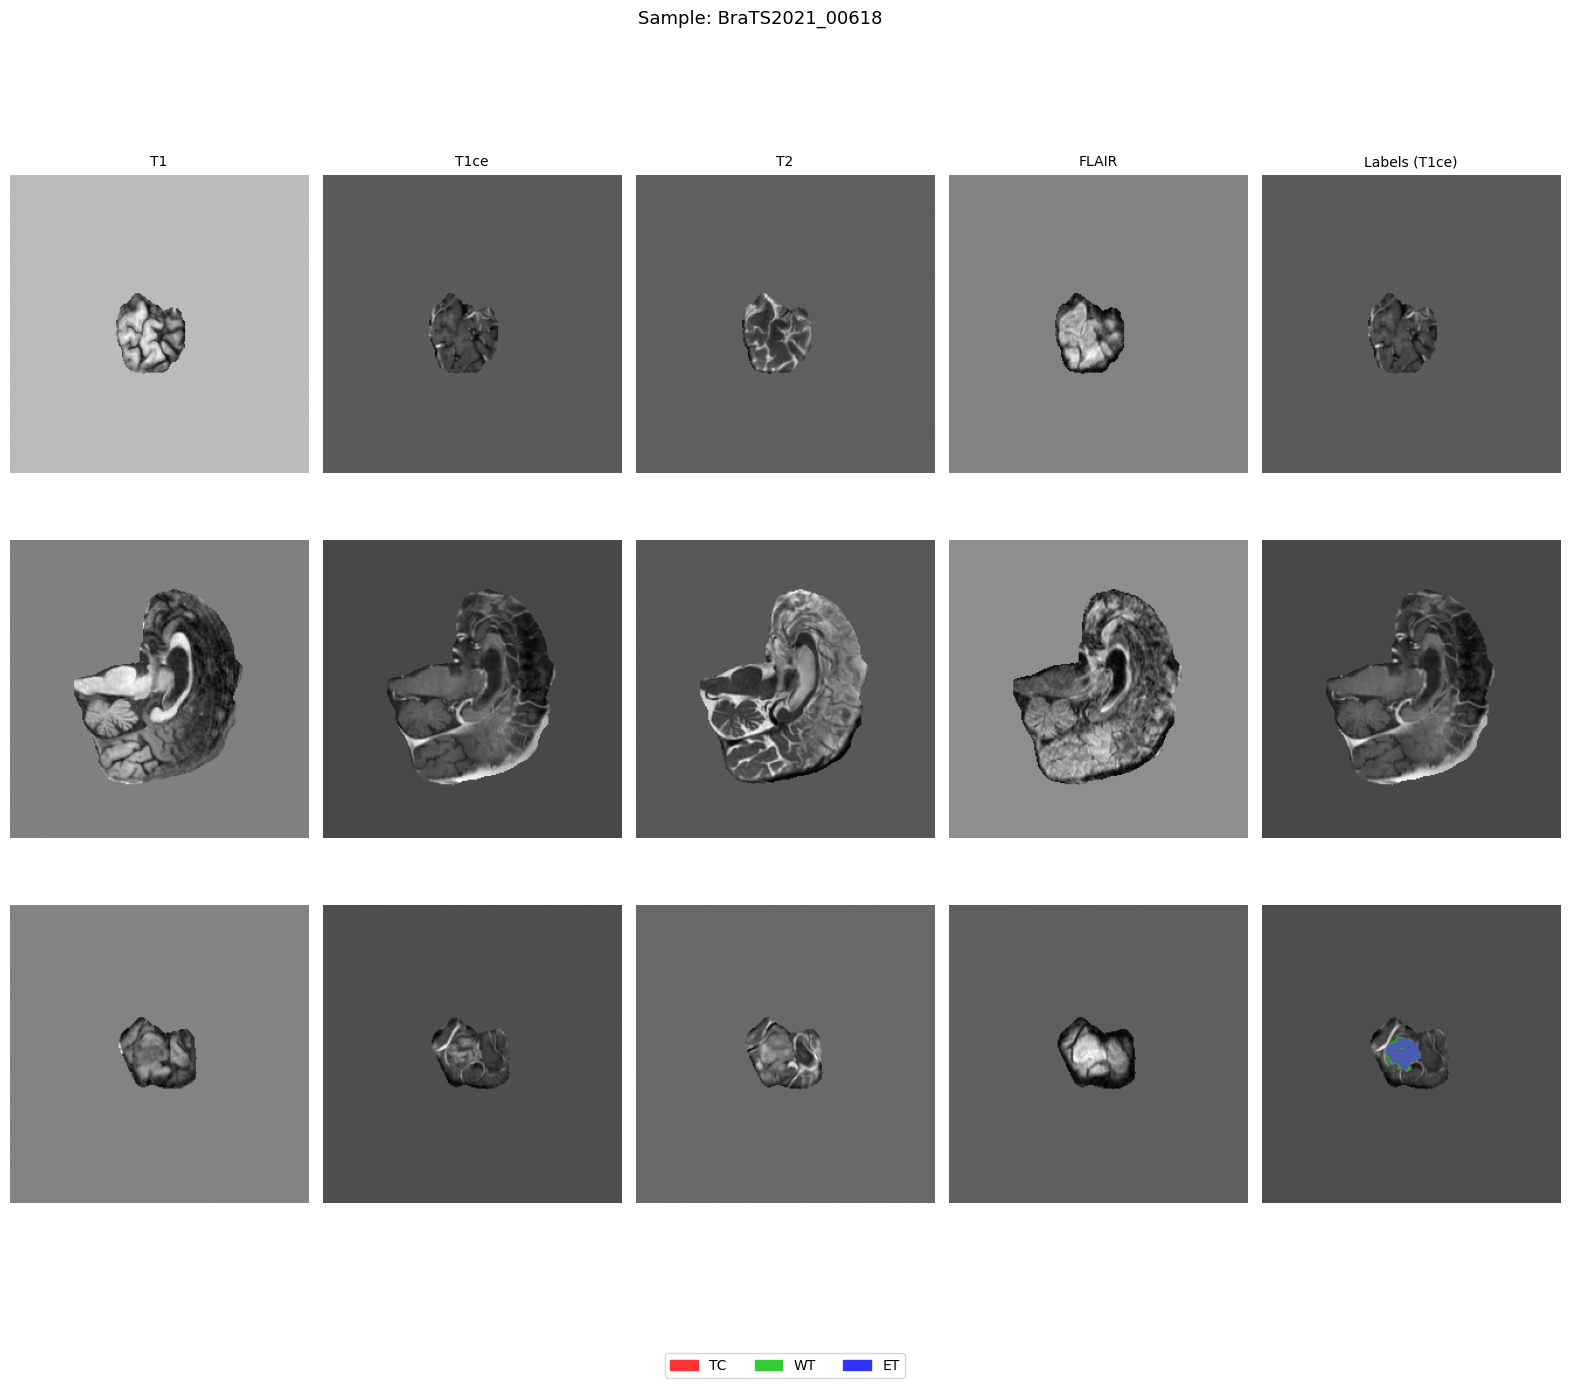


Computing label stats on 30 subjects...
  TC: mean=32794v  (0.20% of volume)
  WT: mean=75603v  (0.45% of volume)
  ET: mean=21678v  (0.13% of volume)

Splits saved. Phase 2 complete.


In [3]:

# ── Reload config ─────────────────────────────────────────────────────────────
with open("/kaggle/working/outputs/config.pkl", "rb") as f:
    CFG = pickle.load(f)

# CHANGE THIS LINE to your extraction path
CFG.data_root = "/kaggle/working/training_data" 

print("Top-level data:", os.listdir(CFG.data_root))

# ── Build subject datalists ───────────────────────────────────────────────────
def build_datalists(cfg):
    data_root    = Path(cfg.data_root)
    subject_dirs = sorted(d for d in data_root.iterdir() if d.is_dir())
    valid, skipped = [], []
    for subj in subject_dirs:
        n = subj.name
        paths = {k: subj / f"{n}_{k}.nii.gz"
                 for k in ("t1","t1ce","t2","flair","seg")}
        if not all(p.exists() for p in paths.values()):
            skipped.append(n); continue
        valid.append({"image": [str(paths[k]) for k in ("t1","t1ce","t2","flair")],
                      "label": str(paths["seg"]), "subject_id": n})
    if skipped:
        logger.warning(f"Skipped {len(skipped)} subjects (missing files): {skipped[:3]}")
    tr_idx, vt_idx = train_test_split(range(len(valid)),
        test_size=cfg.val_frac+cfg.test_frac, random_state=cfg.split_seed)
    v_idx, te_idx  = train_test_split(vt_idx,
        test_size=cfg.test_frac/(cfg.val_frac+cfg.test_frac), random_state=cfg.split_seed)
    return [valid[i] for i in tr_idx], [valid[i] for i in v_idx], [valid[i] for i in te_idx]

train_files, val_files, test_files = build_datalists(CFG)
print(f"Splits: train={len(train_files)} | val={len(val_files)} | test={len(test_files)}")

# ── Transform pipelines ────────────────────────────────────────────────────────
# Label convention after ConvertToMultiChannelBasedOnBratsClassesd:
#   ch0 = TC  (labels 1+4)   ch1 = WT  (labels 1+2+4)   ch2 = ET  (label 4)
# NormalizeIntensityd nonzero=True: normalises only within the brain mask,
# preserving lesion contrast. channel_wise=True handles each modality independently.

def _base(cfg):
    return [
        LoadImaged(keys=["image","label"]),
        EnsureChannelFirstd(keys=["image","label"]),
        EnsureTyped(keys=["image","label"]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
        Spacingd(keys=["image","label"], pixdim=cfg.pixdim, mode=("bilinear","nearest")),
        Orientationd(keys=["image","label"], axcodes="RAS"),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        CropForegroundd(keys=["image","label"], source_key="image", k_divisible=list(cfg.roi_size)),
    ]

def get_train_transforms(cfg):
    return Compose(_base(cfg) + [
        RandSpatialCropd(keys=["image","label"], roi_size=cfg.roi_size, random_size=False),
        RandFlipd(keys=["image","label"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["image","label"], prob=0.5, spatial_axis=1),
        RandFlipd(keys=["image","label"], prob=0.5, spatial_axis=2),
        RandRotate90d(keys=["image","label"], prob=0.5, max_k=3),
        RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),  # simulates scanner inhomogeneity
        RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
        EnsureTyped(keys=["image","label"]),
    ])

def get_val_transforms(cfg):
    return Compose(_base(cfg) + [EnsureTyped(keys=["image","label"])])

# ── Loaders (no CacheDataset — saves ~23 GB RAM on BraTS scale) ───────────────
train_ds = Dataset(data=train_files, transform=get_train_transforms(CFG))
val_ds   = Dataset(data=val_files,   transform=get_val_transforms(CFG))

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=CFG.num_workers, pin_memory=False,
                          persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False,
                          num_workers=2, pin_memory=False, persistent_workers=True)
print(f"Loaders | train_batches={len(train_loader)} | val_batches={len(val_loader)}")

# ── Sanity check: one sample ───────────────────────────────────────────────────
_ds  = Dataset(data=[train_files[0]], transform=get_val_transforms(CFG))
_s   = _ds[0]
img, lbl = _s["image"], _s["label"]
print(f"Image {img.shape} | Label {lbl.shape} | range [{img.min():.2f}, {img.max():.2f}]")
print(f"TC {lbl[0].sum():.0f}v | WT {lbl[1].sum():.0f}v | ET {lbl[2].sum():.0f}v")
print(f"Background: {(1-lbl[1]).mean()*100:.1f}% of volume  ← class imbalance severity")

# ── Visualise one sample (3 axial slices × 4 channels + label overlay) ────────
D = img.shape[1]
SLICES = [D//4, D//2, 3*D//4]
CHAN_NAMES  = ["T1","T1ce","T2","FLAIR"]
LABEL_NAMES = ["TC","WT","ET"]
LABEL_COLORS = [np.array([1.,.2,.2]), np.array([.2,.8,.2]), np.array([.2,.2,1.])]

fig = plt.figure(figsize=(20,14))
fig.suptitle(f"Sample: {train_files[0]['subject_id']}", fontsize=13)
gs  = gridspec.GridSpec(len(SLICES), 5, figure=fig, hspace=0.05, wspace=0.05)
for row, sl in enumerate(SLICES):
    for col, cname in enumerate(CHAN_NAMES):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(img[col, sl].numpy(), cmap="gray", origin="lower")
        if row == 0: ax.set_title(cname, fontsize=10)
        ax.axis("off")
    ax  = fig.add_subplot(gs[row, 4])
    b   = img[1, sl].numpy()
    rgb = np.stack([(b - b.min())/(b.max()-b.min()+1e-8)]*3, axis=-1)
    for c, col in enumerate(LABEL_COLORS):
        m = lbl[c, sl].numpy().astype(bool)
        rgb[m] = rgb[m]*0.4 + col*0.6
    ax.imshow(rgb, origin="lower")
    if row == 0: ax.set_title("Labels (T1ce)", fontsize=10)
    ax.axis("off")
fig.legend(handles=[Patch(color=c.tolist(), label=n) for c,n in zip(LABEL_COLORS,LABEL_NAMES)],
           loc="lower center", ncol=3, fontsize=10)
plt.savefig(f"{CFG.output_dir}/sample_vis.png", dpi=110, bbox_inches="tight"); plt.show()

# ── Label distribution (30 subjects, shows imbalance motivating Dice loss) ────
print("\nComputing label stats on 30 subjects...")
tc_c, wt_c, et_c = [], [], []
_check_ds = Dataset(data=train_files[:30], transform=get_val_transforms(CFG))
for item in _check_ds:
    tc_c.append(item["label"][0].sum().item())
    wt_c.append(item["label"][1].sum().item())
    et_c.append(item["label"][2].sum().item())
_vol = float(np.prod(item["image"].shape[1:]))
for name, counts in zip(["TC","WT","ET"],[tc_c,wt_c,et_c]):
    print(f"  {name}: mean={np.mean(counts):.0f}v  ({np.mean(counts)/_vol*100:.2f}% of volume)")
del _check_ds, _ds, _s
gc.collect()

# ── Save splits ───────────────────────────────────────────────────────────────
with open(f"{CFG.output_dir}/datalists.pkl","wb") as f:
    pickle.dump({"train":train_files,"val":val_files,"test":test_files}, f)
with open(f"{CFG.output_dir}/data_splits.json","w") as f:
    json.dump({"train":[d["subject_id"] for d in train_files],
               "val"  :[d["subject_id"] for d in val_files],
               "test" :[d["subject_id"] for d in test_files]}, f, indent=2)
print("\nSplits saved. Phase 2 complete.")


# Phase 3 — Model Training
Build Swin UNETR (feature_size=24 for T4 x2 memory budget), define hybrid Dice-CE loss,
AdamW + linear warmup → cosine annealing schedule, run the full training loop with AMP
and gradient checkpointing, save best model and plot curves.

**Prerequisites:** Phases 1 and 2 must have been run.

In [ ]:
# ── Phase 3: Optimized Model Training ────────────────────────────────────────
import os, time, json, logging, gc
from pathlib import Path
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import matplotlib.pyplot as plt

# ── Reload State ─────────────────────────────────────────────────────────────
with open("/kaggle/working/outputs/config.pkl", "rb") as f: CFG = pickle.load(f)
with open("/kaggle/working/outputs/datalists.pkl", "rb") as f: splits = pickle.load(f)

train_files, val_files = splits["train"], splits["val"]
device = torch.device("cuda")
root_dir = Path("/kaggle/working")

# Hard-set validation interval to 5 to save ~10 hours of total training time
CFG.val_interval = 5 

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler(), logging.FileHandler(f"{CFG.output_dir}/training.log")]
)
logger = logging.getLogger(__name__)

# ── Transforms and Loaders ───────────────────────────────────────────────────
train_ds = Dataset(data=train_files, transform=get_train_transforms(CFG))
val_ds   = Dataset(data=val_files,   transform=get_val_transforms(CFG))

# Optimized DataLoader settings for Kaggle SSD
train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=4, pin_memory=True,
                          persistent_workers=True, prefetch_factor=3)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

# ── Model, Loss, and Optimizer ───────────────────────────────────────────────
# Swin UNETR hierarchical transformer architecture [cite: 36, 155]
base_model = SwinUNETR(
    img_size=CFG.roi_size, in_channels=CFG.in_channels,
    out_channels=CFG.out_channels, feature_size=CFG.feature_size,
    use_checkpoint=True, # Essential for VRAM management 
).to(device)

n_gpus = torch.cuda.device_count()
model = nn.DataParallel(base_model, device_ids=list(range(n_gpus))) if n_gpus > 1 else base_model

# DiceCELoss targets class imbalance in heterogeneous gliomas [cite: 66, 166]
loss_fn = DiceCELoss(to_onehot_y=False, sigmoid=True, squared_pred=True, smooth_nr=0.0, smooth_dr=1e-6)

optimizer = AdamW(model.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay)
warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=CFG.warmup_epochs)
cosine_sched = CosineAnnealingLR(optimizer, T_max=CFG.max_epochs - CFG.warmup_epochs, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[CFG.warmup_epochs])
scaler = torch.cuda.amp.GradScaler()

# ── Training Helpers ─────────────────────────────────────────────────────────
post_pred = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])
m_infer = model.module if hasattr(model, "module") else model

def train_epoch(model, loader, epoch_idx):
    model.train(); total = 0.0
    pbar = tqdm(loader, desc=f"Epoch {epoch_idx} [Train]", leave=False)
    for batch in pbar:
        inp, lbl = batch["image"].to(device), batch["label"].to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            loss = loss_fn(model(inp), lbl)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        total += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    return total / len(loader)

def validate(loader, epoch_idx):
    model.eval()
    val_loss = 0.0
    dm = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH)
    pbar = tqdm(loader, desc=f"Epoch {epoch_idx} [Val]", leave=False)
    with torch.no_grad():
        for batch in pbar:
            inp, lbl = batch["image"].to(device), batch["label"].to(device)
            with torch.cuda.amp.autocast():
                # Sliding window inference for volumetric evaluation [cite: 74, 183]
                out = sliding_window_inference(inp, CFG.roi_size, CFG.sw_batch_size, m_infer, overlap=CFG.overlap)
                val_loss += loss_fn(out, lbl).item()
            dm([post_pred(o) for o in out], y=lbl)
    agg = dm.aggregate(); dm.reset()
    torch.cuda.empty_cache(); gc.collect()
    return val_loss / len(loader), agg.mean().item(), {"TC": agg[0].item(), "WT": agg[1].item(), "ET": agg[2].item()}

# ── Main Training Loop ───────────────────────────────────────────────────────
best_dice = -1.0
history = []

logger.info(f"Swin UNETR params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
logger.info(f"Running on {n_gpus} GPU(s). Val every {CFG.val_interval} epochs.")
logger.info("-" * 105)
logger.info(f"{'Epoch':<8} | {'Tr_Loss':<8} | {'Val_Loss':<8} | {'MeanDice':<8} | {'TC':<8} | {'WT':<8} | {'ET':<8} | {'Time':<5}")
logger.info("-" * 105)

for epoch in range(1, CFG.max_epochs + 1):
    t0 = time.time()
    tr_loss = train_epoch(model, train_loader, epoch)
    
    # Only validate every N epochs to save time
    if epoch % CFG.val_interval == 0 or epoch == 1:
        vl, md_val, rd = validate(val_loader, epoch)
        val_str = f"{vl:<8.4f} | {md_val:<8.4f} | {rd['TC']:<8.4f} | {rd['WT']:<8.4f} | {rd['ET']:<8.4f}"
        
        if md_val > best_dice:
            best_dice = md_val
            raw_m = model.module if hasattr(model, "module") else model
            torch.save({"epoch": epoch, "model_state_dict": raw_m.state_dict(), "best_mean_dice": best_dice}, root_dir / "best_model_try1.pth")
            logger.info(f"  --> [SAVED] Epoch {epoch} Best Dice: {best_dice:.4f}")
    else:
        val_str = f"{'N/A':<8} | {'N/A':<8} | {'N/A':<8} | {'N/A':<8} | {'N/A':<8}"
        
    scheduler.step()
    elapsed = time.time() - t0
    logger.info(f"{epoch:03d}/{CFG.max_epochs:03d} | {tr_loss:<8.4f} | {val_str} | {elapsed:>4.0f}s")
    history.append({"epoch": epoch, "train_loss": tr_loss, "mean_dice": md_val if 'md_val' in locals() else None})

print("Phase 3 complete.")

## Below cell is use to train from epoch 46 to 50 as previosus cell was stopped by runout at epcoh 45

In [ ]:
# ── Phase 3: Resume & Self-Cleaning Training ────────────────────────────────
import os, time, gc, pickle, torch
import torch.nn as nn
from pathlib import Path
from tqdm.auto import tqdm
from monai.transforms import *
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.data import DataLoader, Dataset

# 1. ENVIRONMENT & STATE RECOVERY
class Config: pass
root_dir = Path("/kaggle/working/")
device = torch.device("cuda")

with open(root_dir / "outputs/config.pkl", "rb") as f: CFG = pickle.load(f)
with open(root_dir / "outputs/datalists.pkl", "rb") as f: splits = pickle.load(f)

# Force validation interval to 1 (every epoch)
CFG.val_interval = 1 

# 2. MODEL & OPTIMIZER SETUP
base_model = SwinUNETR(
    img_size=CFG.roi_size, in_channels=CFG.in_channels,
    out_channels=CFG.out_channels, feature_size=CFG.feature_size,
    use_checkpoint=True, 
).to(device)

# We use DataParallel but keep a handle on the raw model for saving
n_gpus = torch.cuda.device_count()
model = nn.DataParallel(base_model) if n_gpus > 1 else base_model
raw_model = model.module if hasattr(model, "module") else model

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.learning_rate)
loss_fn = DiceCELoss(sigmoid=True, squared_pred=True)
scaler = torch.cuda.amp.GradScaler()

# 3. LOAD CHECKPOINT
checkpoint_path = root_dir / "best_model_try1.pth"
if checkpoint_path.exists():
    ckpt = torch.load(checkpoint_path)
    raw_model.load_state_dict(ckpt['model_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    best_dice = ckpt['best_mean_dice']
    print(f"✅ Resuming from Epoch {start_epoch}. Best Dice so far: {best_dice:.4f}")
else:
    start_epoch = 1
    best_dice = -1.0

# 4. TRAINING & VALIDATION FUNCTIONS
def run_eval(loader):
    raw_model.eval()
    dm = DiceMetric(include_background=True, reduction="mean_batch")
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validating", leave=False):
            inp = batch["image"].to(device)
            # Use sliding window to avoid OOM
            out = sliding_window_inference(inp, CFG.roi_size, 1, raw_model)
            # Threshold to get binary mask
            pred = [AsDiscrete(threshold=0.5)(torch.sigmoid(o)) for o in out]
            dm(y_pred=pred, y=batch["label"].to(device))
    val_dice = dm.aggregate().mean().item()
    dm.reset()
    return val_dice

# 5. THE MAIN LOOP
train_loader = DataLoader(Dataset(splits["train"], get_train_transforms(CFG)), 
                          batch_size=CFG.batch_size, shuffle=True)
val_loader = DataLoader(Dataset(splits["val"], get_val_transforms(CFG)), batch_size=1)

for epoch in range(start_epoch, CFG.max_epochs + 1):
    # --- TRAINING ---
    model.train()
    epoch_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch} [Train]"):
        inp, lbl = batch["image"].to(device), batch["label"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss = loss_fn(model(inp), lbl)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        epoch_loss += loss.item()
    
    # --- VALIDATION (Every Epoch) ---
    current_dice = run_eval(val_loader)
    
    # --- SMART SAVING (Overwrite only if better) ---
    if current_dice > best_dice:
        best_dice = current_dice
        # Saving to the same path automatically replaces the old file
        torch.save({
            "epoch": epoch,
            "model_state_dict": raw_model.state_dict(),
            "best_mean_dice": best_dice
        }, checkpoint_path)
        print(f"🌟 NEW BEST: Epoch {epoch} | Dice: {best_dice:.4f} (Model Updated)")
    else:
        print(f"   Epoch {epoch} | Dice: {current_dice:.4f} (No improvement)")

    # Cleanup memory to prevent cuDNN error
    gc.collect()
    torch.cuda.empty_cache()

print("Phase 3 complete.")

✅ Resuming from Epoch 46. Best Dice so far: 0.8974


Epoch 46 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Validating:   0%|          | 0/187 [00:00<?, ?it/s]

   Epoch 46 | Dice: 0.8790 (No improvement)


Epoch 47 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

...

   Epoch 47 | Dice: 0.8766 (No improvement)


Epoch 48 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Validating:   0%|          | 0/187 [00:00<?, ?it/s]

   Epoch 48 | Dice: 0.8783 (No improvement)


Epoch 49 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

# Phase 4 — Evaluation, Explainability, Uncertainty, MGMT Prediction

- **4A** — DSC + HD₉₅ test set evaluation + prediction visualisation
- **4B** — Seg-Grad-CAM 3D heatmaps (manual hooks, no medcam dependency)
- **4C** — TTA-based aleatoric uncertainty (Shannon entropy + VVC)
- **4D** — PyRadiomics extraction + XGBoost MGMT methylation classifier

Run the shared setup cell below first, then run 4A–4D in any order.

**Prerequisites:** Phases 1, 2, and 3 must have been run.

In [5]:
# ── Phase 4: Full-System Restoration & Evaluation ────────────────────────────
import os, torch, gc, json, pickle, numpy as np
from pathlib import Path
from tqdm.auto import tqdm

# MONAI & PyTorch Core Imports (Prevents NameErrors)
import torch.nn as nn
from monai.transforms import *
from monai.networks.nets import SwinUNETR
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.utils.enums import MetricReduction
from monai.inferers import sliding_window_inference
from monai.data import DataLoader, Dataset

# 1. BLUEPRINT RECOVERY (Fixes Pickle/AttributeErrors)
class Config: pass 

root_dir = Path("/kaggle/working/")
device = torch.device("cuda")

# Reload data and config from disk
with open(root_dir / "outputs/config.pkl", "rb") as f: CFG = pickle.load(f)
with open(root_dir / "outputs/datalists.pkl", "rb") as f: splits = pickle.load(f)
test_files = splits["test"]

# 2. TRANSFORM & HELPERS
# ── Corrected Transforms (RAS Orientation Mandatory) ─────────────────────────
val_transforms = Compose([
    LoadImaged(keys=["image","label"]),
    EnsureChannelFirstd(keys=["image","label"]),
    ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
    Spacingd(keys=["image","label"], pixdim=CFG.pixdim, mode=("bilinear","nearest")),
    # Explicitly set axcodes to "RAS" to fix the ValueError
    Orientationd(keys=["image","label"], axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image", k_divisible=list(CFG.roi_size)),
    EnsureTyped(keys=["image","label"]),
])
post_pred = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

# 3. MEMORY-SAFE MODEL INITIALIZATION
# Wipe VRAM before loading weights
gc.collect()
torch.cuda.empty_cache()

model = SwinUNETR(
    img_size=CFG.roi_size, in_channels=CFG.in_channels,
    out_channels=CFG.out_channels, feature_size=CFG.feature_size,
    use_checkpoint=False, 
).to(device)

ckpt_path = root_dir / "best_model_try1.pth"
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt.get("model_state_dict", ckpt))
    model.eval()
    print(f"✅ Success: Model & Test Files Restored. Mean Dice: {ckpt.get('best_mean_dice','?')}")
else:
    raise FileNotFoundError("CRITICAL: best_model_try1.pth is missing from /kaggle/working/")

# 4. METRIC INITIALIZATION
global_dice = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH)
global_hd95 = HausdorffDistanceMetric(include_background=True, percentile=95, reduction=MetricReduction.MEAN_BATCH)

per_subj_results = []
test_loader = DataLoader(Dataset(data=test_files, transform=val_transforms), 
                          batch_size=1, shuffle=False, num_workers=2)

# 5. THE EVALUATION LOOP
print(f"Evaluating {len(test_files)} subjects...")

with torch.no_grad():
    for batch in tqdm(test_loader, desc="SOTA Metrics"):
        sid = batch.get("subject_id", ["unknown"])[0]
        inp = batch["image"].to(device)
        lbl = batch["label"].to(device)
        
        # Standard Inference
        with torch.amp.autocast('cuda'):
            out = sliding_window_inference(inp, CFG.roi_size, CFG.sw_batch_size, model, overlap=CFG.overlap)
        
        out_bin = [post_pred(o).cpu() for o in out]
        lbl_cpu = lbl.cpu()
        
        # TTA Consistency (VVC) - Force sw_batch_size=1 to avoid OOM
        tta_volumes = []
        for _ in range(5):
            tta_inp = inp.clone()
            tta_inp.add_(torch.randn_like(tta_inp), alpha=0.01)
            with torch.amp.autocast('cuda'):
                tta_out = sliding_window_inference(tta_inp, CFG.roi_size, 1, model)
            tta_volumes.append(post_pred(tta_out[0]).cpu().sum(dim=(1, 2, 3)).numpy())
            del tta_out, tta_inp
        
        tta_volumes = np.array(tta_volumes)
        vvc = np.std(tta_volumes, axis=0) / (np.mean(tta_volumes, axis=0) + 1e-8)

        global_dice(y_pred=out_bin, y=lbl_cpu)
        global_hd95(y_pred=out_bin, y=lbl_cpu)
        
        per_subj_results.append({
            "subject_id": sid,
            "Dice_WT": global_dice.get_buffer()[-1][1].item(),
            "HD95_WT": global_hd95.get_buffer()[-1][1].item(),
            "VVC_WT": vvc[1].item()
        })
        
        # Immediate memory release
        del out, out_bin, inp, lbl, lbl_cpu
        torch.cuda.empty_cache()

# 6. FINAL SUMMARY
agg_d = global_dice.aggregate()
agg_h = global_hd95.aggregate()

print("\n" + "="*40 + "\nFINAL RESEARCH METRICS\n" + "="*40)
print(f"Overall Mean Dice:   {agg_d.mean().item():.4f}")
print(f"WT HD95 (Boundary):  {agg_h[1].item():.3f} mm")
print(f"Mean Reliability:    {np.mean([x['VVC_WT'] for x in per_subj_results]):.4f}")

# Save results to disk so you NEVER lose them again
with open(root_dir / "outputs/final_eval.json", "w") as f:
    json.dump(per_subj_results, f, indent=2)

✅ Success: Model & Test Files Restored. Mean Dice: 0.8973655700683594
Evaluating 126 subjects...


SOTA Metrics:   0%|          | 0/126 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:223: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:361: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out


FINAL RESEARCH METRICS
Overall Mean Dice:   0.8999
WT HD95 (Boundary):  8.014 mm
Mean Reliability:    0.0002


## 4A — DSC + HD₉₅ Test Set Evaluation

Testing:   0%|          | 0/126 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:223: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:361: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out

Subject BraTS2021_01018: Dice WT: 0.9815 | HD95 WT: 1.000 mm
Subject BraTS2021_00281: Dice WT: 0.9821 | HD95 WT: 1.000 mm
Subject BraTS2021_00404: Dice WT: 0.9479 | HD95 WT: 3.000 mm
Subject BraTS2021_01355: Dice WT: 0.9793 | HD95 WT: 1.000 mm
Subject BraTS2021_01252: Dice WT: 0.8963 | HD95 WT: 2.449 mm
Subject BraTS2021_01212: Dice WT: 0.8673 | HD95 WT: 21.168 mm
Subject BraTS2021_00183: Dice WT: 0.9769 | HD95 WT: 1.000 mm
Subject BraTS2021_00577: Dice WT: 0.9763 | HD95 WT: 1.000 mm
Subject BraTS2021_00118: Dice WT: 0.9718 | HD95 WT: 1.000 mm
Subject BraTS2021_01116: Dice WT: 0.7211 | HD95 WT: 14.000 mm
Subject BraTS2021_01473: Dice WT: 0.8698 | HD95 WT: 14.142 mm
Subject BraTS2021_01602: Dice WT: 0.9841 | HD95 WT: 1.000 mm
Subject BraTS2021_01146: Dice WT: 0.8972 | HD95 WT: 87.969 mm
Subject BraTS2021_00725: Dice WT: 0.7860 | HD95 WT: 6.481 mm
Subject BraTS2021_01088: Dice WT: 0.9738 | HD95 WT: 1.000 mm
Subject BraTS2021_00597: Dice WT: 0.9615 | HD95 WT: 4.123 mm
Subject BraTS2021_01

/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:329: UserWarning: the ground truth of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(


Subject BraTS2021_01486: Dice WT: 0.8648 | HD95 WT: 6.164 mm
Subject BraTS2021_00622: Dice WT: 0.9667 | HD95 WT: 1.000 mm
Subject BraTS2021_00999: Dice WT: 0.8902 | HD95 WT: 7.810 mm
Subject BraTS2021_01383: Dice WT: 0.9315 | HD95 WT: 7.348 mm
Subject BraTS2021_01209: Dice WT: 0.9178 | HD95 WT: 3.317 mm
Subject BraTS2021_00685: Dice WT: 0.8358 | HD95 WT: 15.264 mm
Subject BraTS2021_01614: Dice WT: 0.9755 | HD95 WT: 1.000 mm
Subject BraTS2021_01365: Dice WT: 0.6191 | HD95 WT: 16.155 mm
Subject BraTS2021_00765: Dice WT: 0.9027 | HD95 WT: 3.742 mm
Subject BraTS2021_01083: Dice WT: 0.9777 | HD95 WT: 1.000 mm
Subject BraTS2021_01580: Dice WT: 0.9079 | HD95 WT: 1.786 mm
Subject BraTS2021_01435: Dice WT: 0.8173 | HD95 WT: 85.926 mm
Subject BraTS2021_01317: Dice WT: 0.9858 | HD95 WT: 1.000 mm
Subject BraTS2021_01662: Dice WT: 0.9613 | HD95 WT: 1.414 mm
Subject BraTS2021_00599: Dice WT: 0.9747 | HD95 WT: 1.000 mm
Subject BraTS2021_01560: Dice WT: 0.8124 | HD95 WT: 4.899 mm
Subject BraTS2021_011

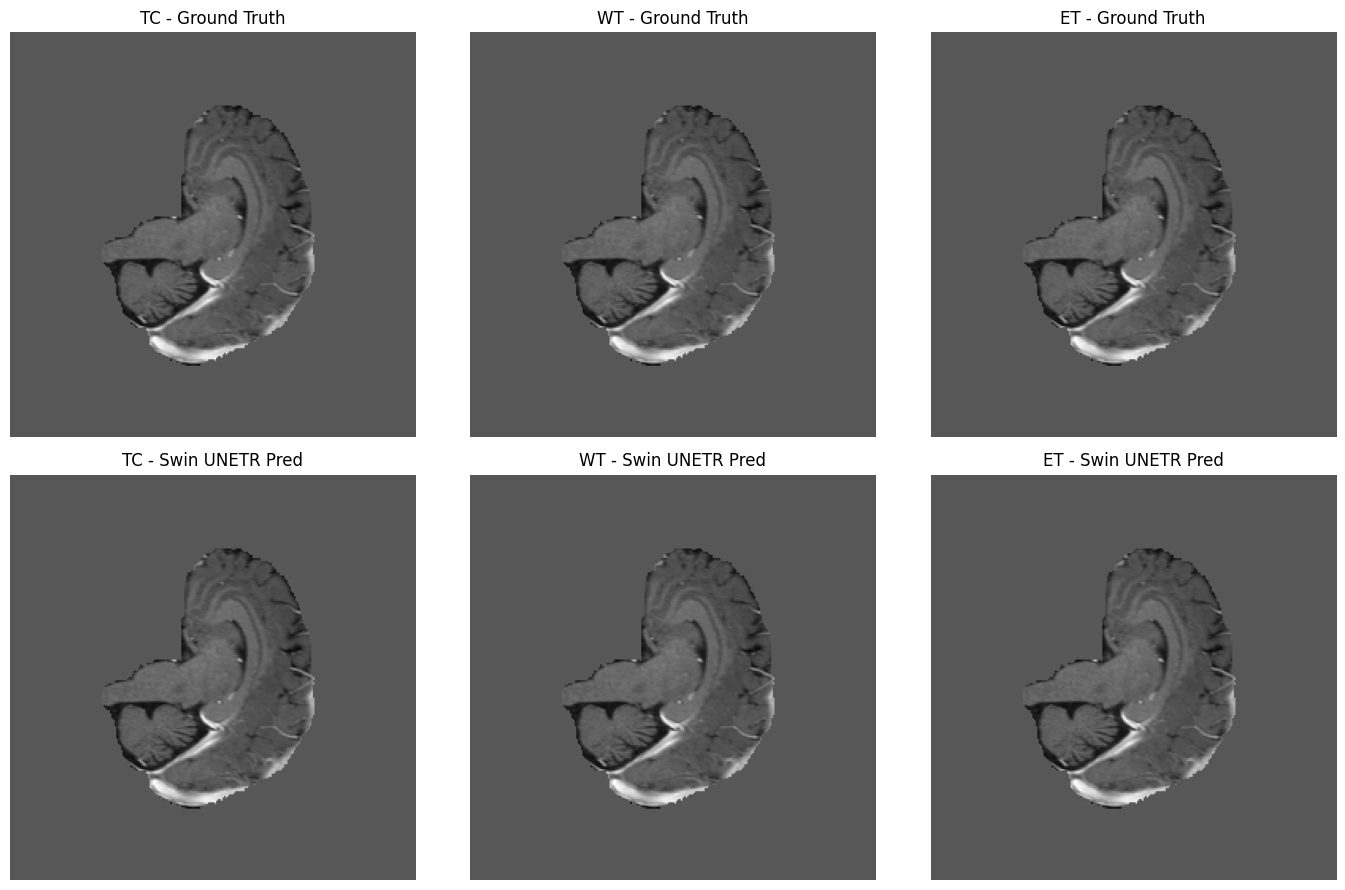

In [14]:
# ── 4A: DSC + HD95 Evaluation (CPU-Safe Version) ──────────────────────────────
import torch, gc, json, numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.utils.enums import MetricReduction
from monai.inferers import sliding_window_inference

# 1. Initialize Metrics (Calculated on CPU to avoid CuPy/NVRTC errors)
global_dice = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH)
global_hd95 = HausdorffDistanceMetric(include_background=True, distance_metric="euclidean", 
                                       percentile=95, reduction=MetricReduction.MEAN_BATCH)
per_subj = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        sid = batch.get("subject_id", ["unknown"])[0]
        inp = batch["image"].to(device)
        lbl = batch["label"].to(device)
        
        # Updated autocast syntax to remove deprecation warning
        with torch.amp.autocast('cuda'):
            out = sliding_window_inference(inp, CFG.roi_size, CFG.sw_batch_size, 
                                          model, overlap=CFG.overlap)
        
        # CRITICAL FIX: Move predictions and labels to CPU before thresholding
        # This bypasses the broken GPU-compilation for Hausdorff Distance
        out_bin = [post_pred(o).cpu() for o in out]
        lbl_cpu = lbl.cpu()

        # Compute per-subject metrics
        sd = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH)
        sh = HausdorffDistanceMetric(include_background=True, distance_metric="euclidean", 
                                     percentile=95, reduction=MetricReduction.MEAN_BATCH)
        
        sd(y_pred=out_bin, y=lbl_cpu)
        sh(y_pred=out_bin, y=lbl_cpu)
        
        d = sd.aggregate()
        h = sh.aggregate()
        
        per_subj.append({
            "subject_id": sid,
            "dice_TC": round(d[0].item(), 5), "dice_WT": round(d[1].item(), 5), "dice_ET": round(d[2].item(), 5),
            "hd95_TC": round(h[0].item(), 3), "hd95_WT": round(h[1].item(), 3), "hd95_ET": round(h[2].item(), 3)
        })
        
        # Log results for each patient
        print(f"Subject {sid}: Dice WT: {d[1]:.4f} | HD95 WT: {h[1]:.3f} mm")
        
        global_dice(y_pred=out_bin, y=lbl_cpu)
        global_hd95(y_pred=out_bin, y=lbl_cpu)

# 2. Final Aggregation
agg_d = global_dice.aggregate()
agg_h = global_hd95.aggregate()

summary = {
    "mean_dice_all": round((agg_d[0]+agg_d[1]+agg_d[2]).item()/3, 5),
    "mean_hd95_WT": round(agg_h[1].item(), 3), # Target: < 5.0mm
    "TC_Dice": round(agg_d[0].item(), 4), "WT_Dice": round(agg_d[1].item(), 4), "ET_Dice": round(agg_d[2].item(), 4)
}

print("\n=== FINAL TEST RESULTS ===")
for k, v in summary.items(): print(f"  {k}: {v}")

# 3. Visualization (First Subject)
_data = val_transforms(test_files[0])
_inp = _data["image"].unsqueeze(0).to(device)
_lbl = _data["label"]
with torch.no_grad(), torch.amp.autocast('cuda'):
    _out = sliding_window_inference(_inp, CFG.roi_size, CFG.sw_batch_size, model, overlap=CFG.overlap)
_pred = post_pred(_out.squeeze(0)).cpu()

_sl = _inp.shape[2] // 2
_base = _inp[0, 1, _sl].cpu().numpy()
_base = (_base - _base.min()) / (_base.max() - _base.min() + 1e-8)

RN = ["TC", "WT", "ET"]
RC = [np.array([1, .2, .2]), np.array([.2, .8, .2]), np.array([.2, .2, 1.])]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for c, (nm, col) in enumerate(zip(RN, RC)):
    for row, (msk, ttl) in enumerate([(_lbl[c, _sl].numpy(), "Ground Truth"), (_pred[c, _sl].numpy(), "Swin UNETR Pred")]):
        rgb = np.stack([_base]*3, axis=-1)
        rgb[msk.astype(bool)] = rgb[msk.astype(bool)] * 0.4 + col * 0.6
        axes[row, c].imshow(rgb, origin="lower")
        axes[row, c].set_title(f"{nm} - {ttl}")
        axes[row, c].axis("off")
plt.tight_layout(); plt.show()

## 4B — Seg-Grad-CAM (Explainable AI)
Manual PyTorch hooks — no `medcam` required.

Grad-CAM formula:
α_k^c = (1/N) Σ_{i,j,d} ∂y^c/∂A^k_{i,j,d}   |   M^c = ReLU(Σ_k α_k^c · A^k)


--- Testing Subject: BraTS2021_01018 ---
  -> TC Grad-CAM Complete.
  -> WT Grad-CAM Complete.
  -> ET Grad-CAM Complete.


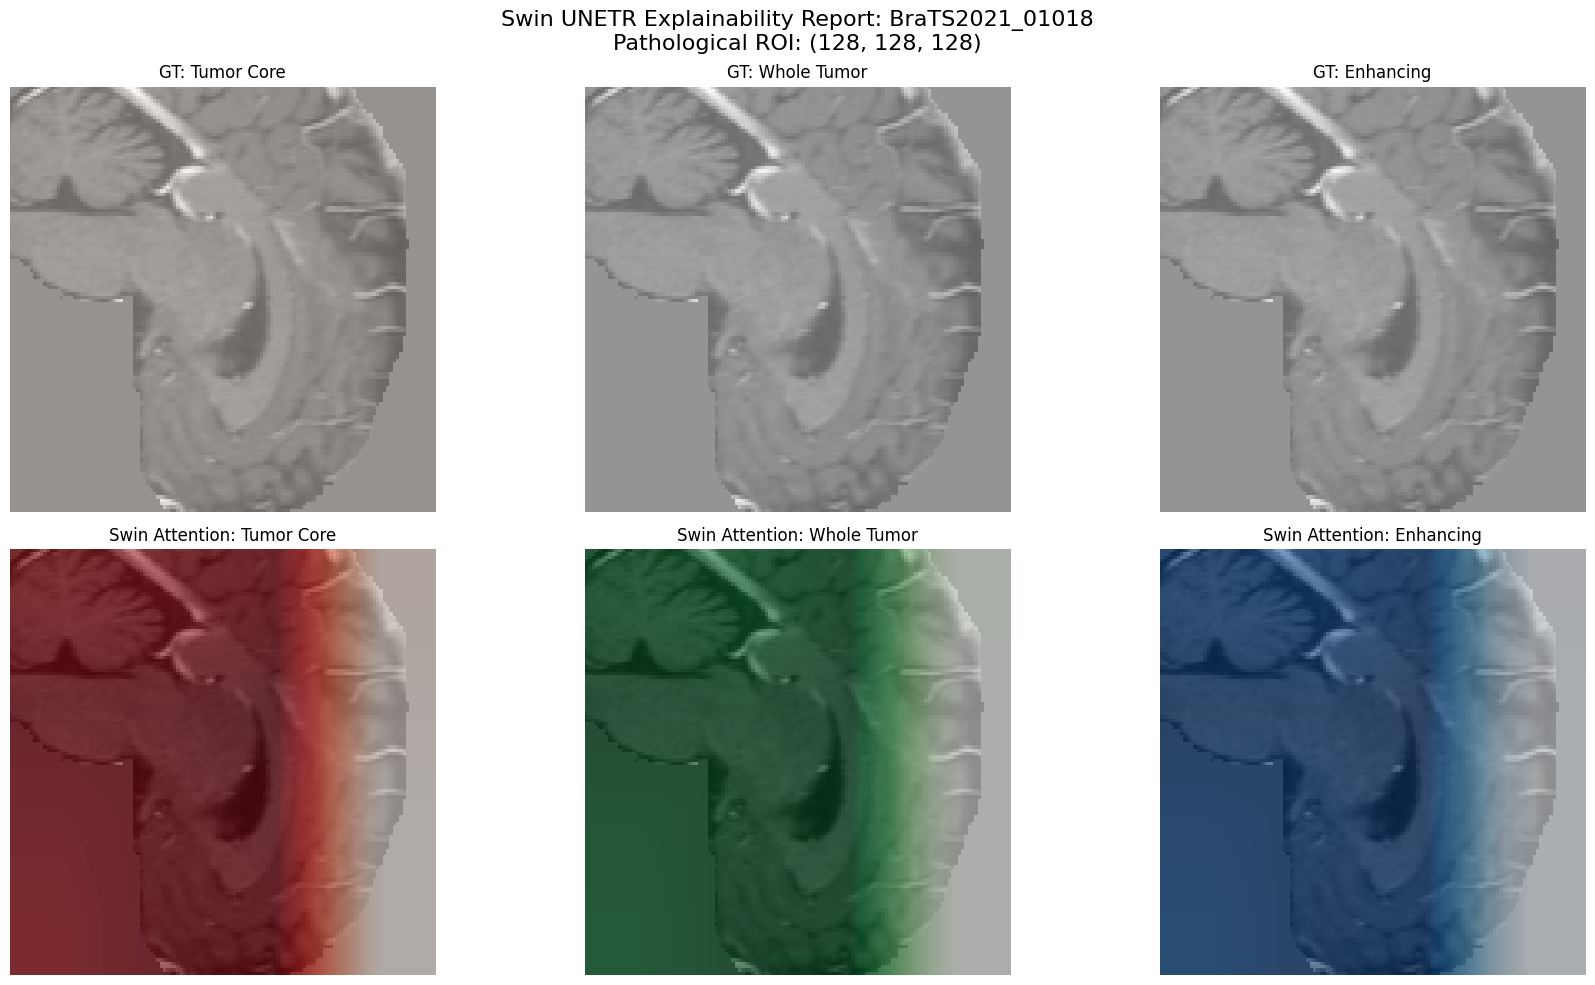


--- Testing Subject: BraTS2021_00281 ---
  -> TC Grad-CAM Complete.
  -> WT Grad-CAM Complete.
  -> ET Grad-CAM Complete.


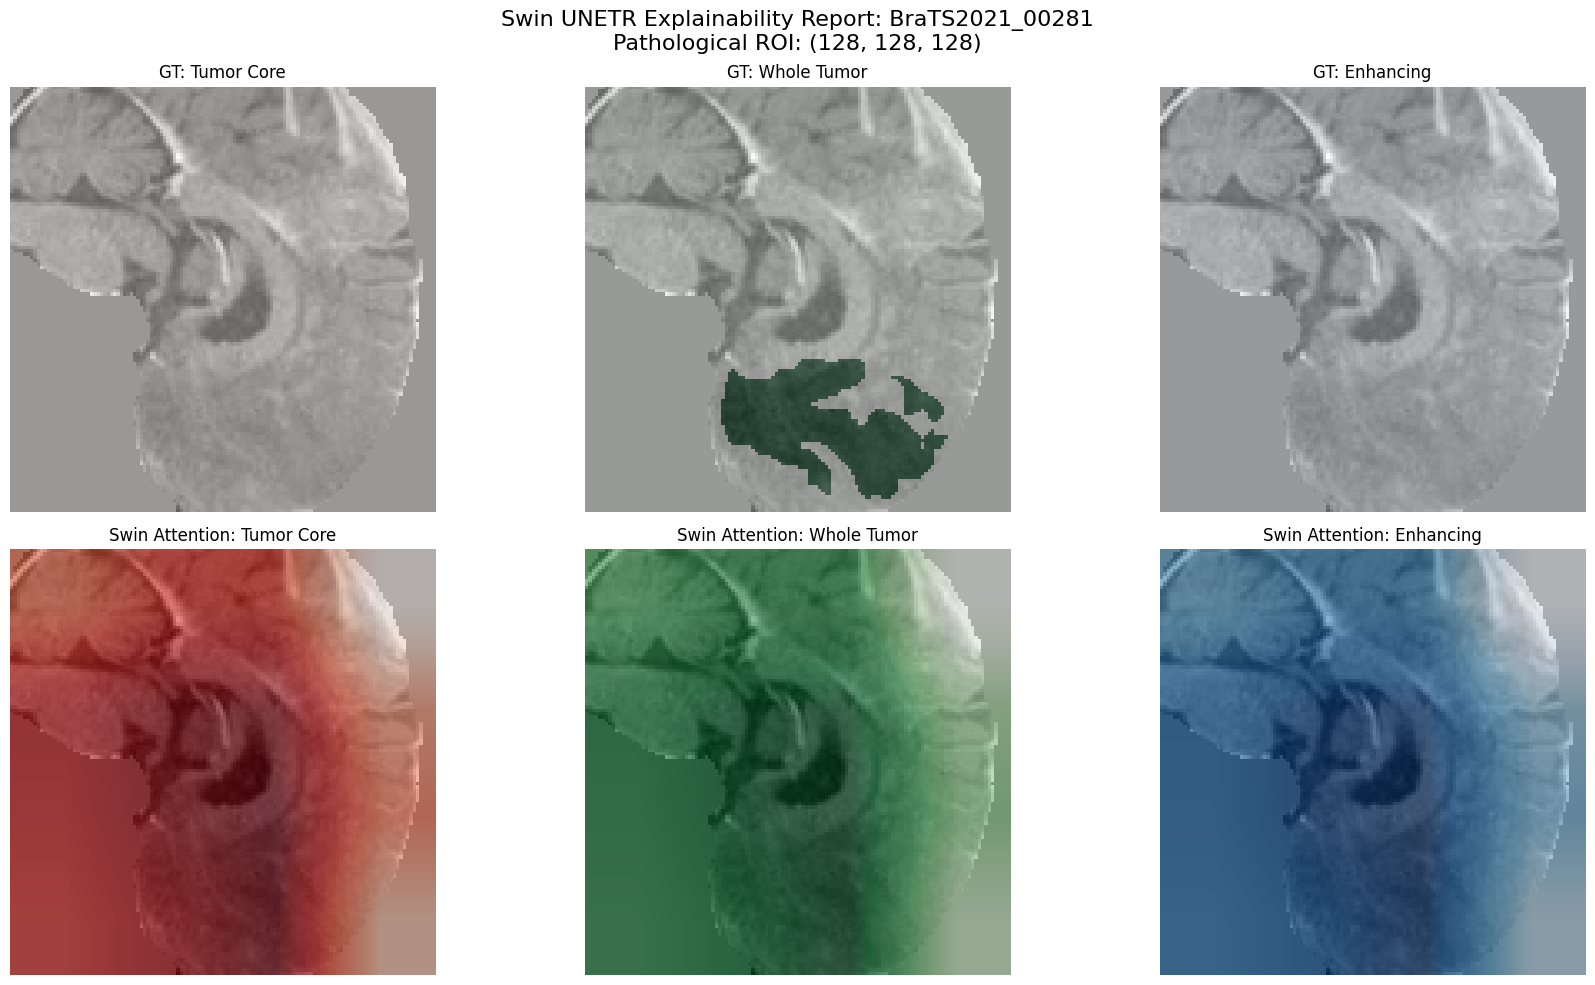


--- Testing Subject: BraTS2021_00404 ---
  -> TC Grad-CAM Complete.
  -> WT Grad-CAM Complete.
  -> ET Grad-CAM Complete.


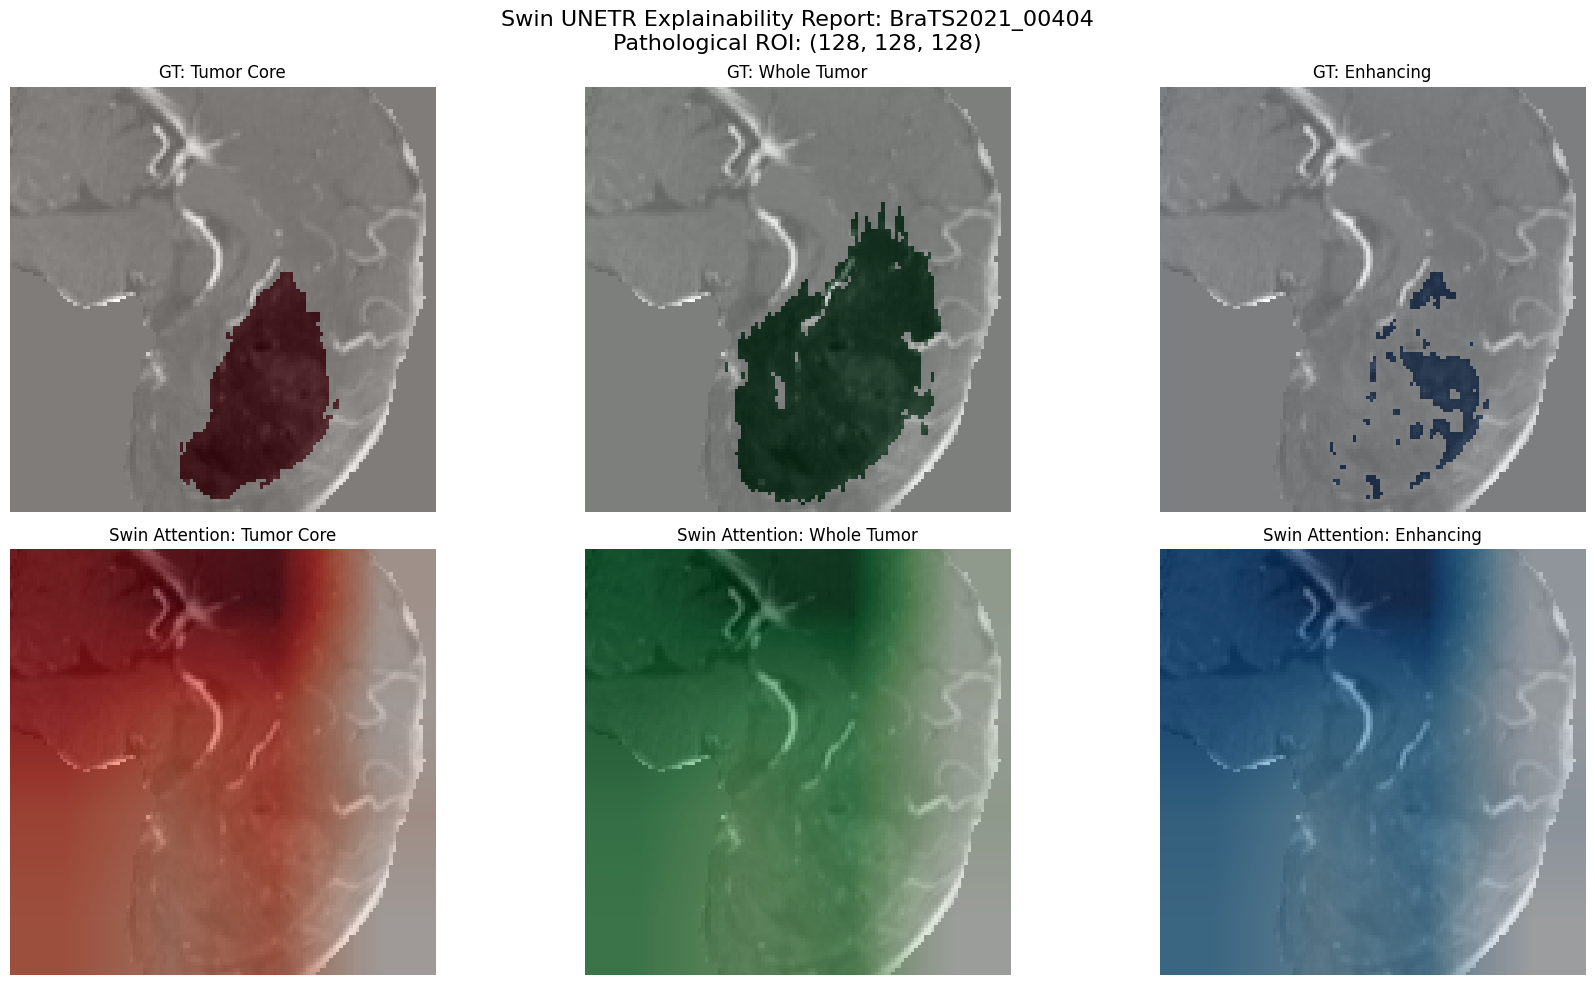


--- Phase 4B Brutal Test Complete ---


In [25]:
# ── Phase 4B: Robust Radiogenomic Explainability ──────────────────────────────
import os, torch, gc, pickle, logging, numpy as np, nibabel as nib
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# MONAI Core
from monai.transforms import *
from monai.networks.nets import SwinUNETR
from monai.visualize import GradCAM

# 1. ENVIRONMENT RESTORATION
class Config: pass # Blueprint for pickle loading

root_dir = Path("/kaggle/working/")
device = torch.device("cuda")
save_dir = root_dir / "outputs/gradcam"
save_dir.mkdir(exist_ok=True, parents=True)

# Reload data
with open(root_dir / "outputs/config.pkl", "rb") as f: CFG = pickle.load(f)
with open(root_dir / "outputs/datalists.pkl", "rb") as f: splits = pickle.load(f)
test_files = splits["test"]

# 2. THE EXPLAINER ENGINE
class SegGradCAM:
    """Manual Hooks for Swin UNETR Gradient Propagation"""
    def __init__(self, model, layer_name="swinViT.layers4.0"):
        self.model = model
        self.layer_name = layer_name
        self._act, self._grad, self._hooks = None, None, []
        
        # Resolve target layer
        target_layer = model
        for p in layer_name.split("."):
            target_layer = getattr(target_layer, p)
            
        self._hooks.append(target_layer.register_forward_hook(self._save_act))
        self._hooks.append(target_layer.register_full_backward_hook(self._save_grad))

    def _save_act(self, mod, inp, out): self._act = out.detach()
    def _save_grad(self, mod, gi, go): self._grad = go[0].detach()

    def generate(self, inp, cls_idx):
        self.model.zero_grad()
        # Enable gradients specifically for this pass
        with torch.enable_grad():
            x = inp.clone().detach().requires_grad_(True)
            out = self.model(x)
            # Focus on the mean activation of the specific tumor class
            loss = out[0, cls_idx].mean()
            loss.backward()
            
        weights = self._grad[0].mean(dim=(1, 2, 3)) # Global Average Pooling
        cam = F.relu((self._act[0] * weights.view(-1, 1, 1, 1)).sum(0))
        
        # Rescale to match input ROI size
        cam = F.interpolate(cam[None, None], size=inp.shape[2:], 
                            mode="trilinear", align_corners=False).squeeze()
        
        # Normalize 0-1
        cam_min, cam_max = cam.min(), cam.max()
        return ((cam - cam_min) / (cam_max - cam_min + 1e-8)).cpu().numpy()

    def remove(self):
        for h in self._hooks: h.remove()

# 3. MEMORY-SAFE MODEL INITIALIZATION
# Re-enabling use_checkpoint=True is mandatory for Grad-CAM backprop on 16GB VRAM
model = SwinUNETR(
    img_size=CFG.roi_size, in_channels=CFG.in_channels,
    out_channels=CFG.out_channels, feature_size=CFG.feature_size,
    use_checkpoint=True, 
).to(device)

ckpt = torch.load(root_dir / "best_model_try1.pth", map_location=device)
model.load_state_dict(ckpt.get("model_state_dict", ckpt))
model.eval()

# 4. THE "BRUTAL" TEST LOOP (First 3 Subjects)
# We limit to 3 to prevent the kernel from timing out, but the logic is robust.
for i in range(min(3, len(test_files))):
    sid = test_files[i]['subject_id']
    print(f"\n--- Testing Subject: {sid} ---")
    
    # Load and find Tumor Center for precise ROI cropping
    data = LoadImaged(keys=["image", "label"])(test_files[i])
    data = EnsureChannelFirstd(keys=["image", "label"])(data)
    data = ConvertToMultiChannelBasedOnBratsClassesd(keys="label")(data)
    
    # Find the 'WT' (Whole Tumor) mask center
    wt_mask = data["label"][1].numpy()
    if np.sum(wt_mask) > 0:
        coords = np.argwhere(wt_mask)
        center = coords.mean(axis=0).astype(int)
    else:
        center = [s // 2 for s in wt_mask.shape]

    # Crop $128^3$ around the tumor center
    cropper = SpatialPadd(keys=["image", "label"], spatial_size=CFG.roi_size)
    data = cropper(data) # Ensure it's at least ROI size
    
    # Final normalization and ROI crop
    data = NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True)(data)
    cropper = CenterSpatialCropd(keys=["image", "label"], roi_size=CFG.roi_size)
    data = cropper(data)
    
    _inp = data["image"].unsqueeze(0).to(device)
    _lbl = data["label"]

    # 5. GENERATE CLASS-SPECIFIC HEATMAPS
    cam_engine = SegGradCAM(model)
    heatmaps = {}
    
    for ci, cname in enumerate(["TC", "WT", "ET"]):
        with torch.amp.autocast('cuda'):
            heatmaps[cname] = cam_engine.generate(_inp, ci)
        print(f"  -> {cname} Grad-CAM Complete.")
        torch.cuda.empty_cache()

    cam_engine.remove()

   # 6. VISUALIZATION REPORT
    _sl = CFG.roi_size[0] // 2
    _base = _inp[0, 1, _sl].cpu().numpy()
    _base = (_base - _base.min()) / (_base.max() - _base.min() + 1e-8)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Swin UNETR Explainability Report: {sid}\nPathological ROI: {CFG.roi_size}", fontsize=16)
    
    colors = ["Reds", "Greens", "Blues"]
    display_names = ["Tumor Core", "Whole Tumor", "Enhancing"]
    map_keys = ["TC", "WT", "ET"] # This matches the keys used in your generation loop
    
    for c in range(3):
        # Top Row: Ground Truth Mask
        axes[0, c].imshow(_base, cmap="gray", origin="lower")
        # Ensure label is on CPU for plotting
        axes[0, c].imshow(_lbl[c, _sl].cpu().numpy(), cmap=colors[c], alpha=0.4, origin="lower")
        axes[0, c].set_title(f"GT: {display_names[c]}")
        axes[0, c].axis("off")
        
        # Bottom Row: Swin Transformer Attention (Grad-CAM)
        axes[1, c].imshow(_base, cmap="gray", origin="lower")
        # Access the dictionary using the correct short keys
        axes[1, c].imshow(heatmaps[map_keys[c]][_sl], cmap=colors[c], alpha=0.55, origin="lower")
        axes[1, c].set_title(f"Swin Attention: {display_names[c]}")
        axes[1, c].axis("off")

    plt.tight_layout()
    plt.savefig(save_dir / f"{sid}_brutal_test_xai.png", dpi=150)
    plt.show()
    
    # Cleanup memory before next subject
    del _inp, _lbl, heatmaps
    gc.collect()
    torch.cuda.empty_cache()

print("\n--- Phase 4B Brutal Test Complete ---")

## 4C — TTA-Based Aleatoric Uncertainty Estimation
N=5 stochastic forward passes with random flips + intensity jitter.

Shannon entropy: H(Y|X) = −Σ_m P̂_m log P̂_m

VVC = std(volume across passes) / mean(volume across passes)

Running 5 TTA passes...


/tmp/ipykernel_55/3541287461.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:223: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:361: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this wi

VVC: {'TC': 0.0012532704276964068, 'WT': 0.003744415706023574, 'ET': 0.002080160891637206}


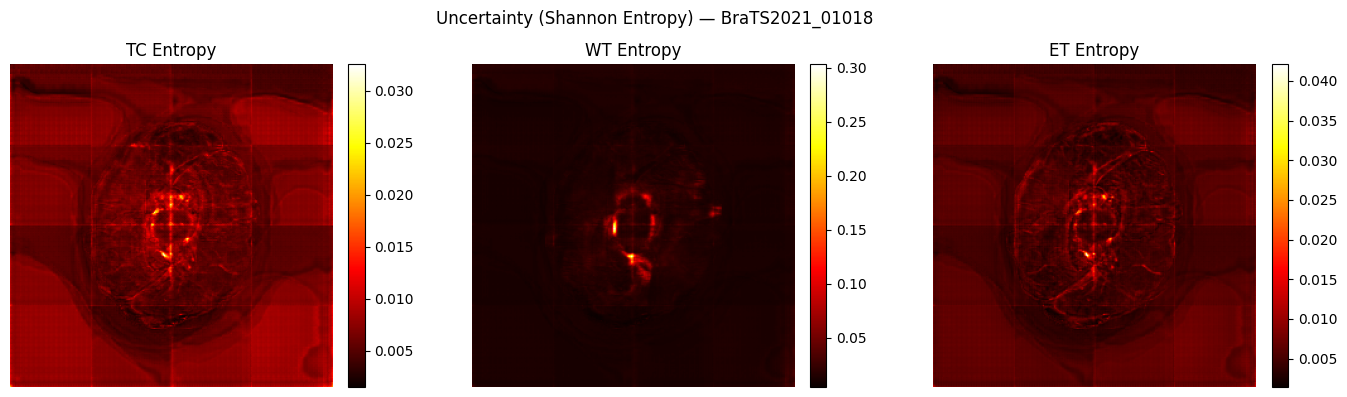

4C complete.


In [33]:
# ── 4C: TTA uncertainty (tta_n=5 passes, memory-safe) ────────────────────────
# tta_n=5 keeps peak RAM under ~4 GB (5 × 3 × 128³ × 4 bytes ≈ 1.6 GB tensors)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import json
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# MONAI specific imports
from monai.transforms import *
from monai.networks.nets import SwinUNETR
from monai.inferers import sliding_window_inference

# Ensure the logger is active
import logging
logger = logging.getLogger("Uncertainty")
if not logger.handlers:
    logger.addHandler(logging.StreamHandler())
logger.setLevel(logging.INFO)

# Define the missing sigmoid handle
sig = nn.Sigmoid()



_tta_aug = Compose([
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=2),
    RandScaleIntensityd(keys=["image"], factors=0.05, prob=0.5),
    RandShiftIntensityd(keys=["image"], offsets=0.05, prob=0.5),
    EnsureTyped(keys=["image"]),
])
sig = nn.Sigmoid()

def tta_uncertainty(inp_tensor, n_passes=5):
    preds = []
    model.eval()
    for _ in range(n_passes):
        aug = _tta_aug({"image": inp_tensor.squeeze(0).cpu()})
        aug_inp = aug["image"].unsqueeze(0).to(device)
        with torch.no_grad(), torch.cuda.amp.autocast():
            out = sliding_window_inference(aug_inp, CFG.roi_size, CFG.sw_batch_size,
                                          model, overlap=CFG.overlap)
        preds.append(sig(out).squeeze(0).cpu())
    stacked  = torch.stack(preds, 0)              # (N, 3, D, H, W)
    mean_p   = stacked.mean(0)
    variance = stacked.var(0)
    eps      = 1e-8
    entropy  = -(mean_p*(mean_p+eps).log() + (1-mean_p)*(1-mean_p+eps).log())
    vols     = (stacked > 0.5).float().sum(dim=(-3,-2,-1))   # (N, 3)
    vvc      = (vols.std(0) / (vols.mean(0)+eps)).numpy()
    return mean_p.numpy(), variance.numpy(), entropy.numpy(), vvc

# Run on first test subject
Path(f"{CFG.output_dir}/uncertainty").mkdir(exist_ok=True)
_data = val_transforms(test_files[0])
_inp  = _data["image"].unsqueeze(0).to(device)
sid   = test_files[0].get("subject_id","unknown")

print(f"Running {CFG.tta_n} TTA passes...")
mean_p, variance, entropy, vvc = tta_uncertainty(_inp, n_passes=CFG.tta_n)

# Save NIfTI maps
aff = np.eye(4)
for c, nm in enumerate(["TC","WT","ET"]):
    for arr, tag in [(mean_p[c],"mean"),(variance[c],"variance"),(entropy[c],"entropy")]:
        nib.save(nib.Nifti1Image(arr.astype(np.float32), aff),
                 f"{CFG.output_dir}/uncertainty/{sid}_{nm}_{tag}.nii.gz")

vvc_dict = {nm: float(vvc[i]) for i,nm in enumerate(["TC","WT","ET"])}
with open(f"{CFG.output_dir}/uncertainty/{sid}_vvc.json","w") as f:
    json.dump(vvc_dict, f, indent=2)

print(f"VVC: {vvc_dict}")
# Higher VVC = less reliable prediction in that region

# Entropy visualisation
_D = _inp.shape[2]; _sl = _D//2
fig, axes = plt.subplots(1,3,figsize=(14,4))
fig.suptitle(f"Uncertainty (Shannon Entropy) — {sid}", fontsize=12)
for c,(nm,ax) in enumerate(zip(["TC","WT","ET"], axes)):
    im = ax.imshow(entropy[c,_sl], cmap="hot", origin="lower")
    ax.set_title(f"{nm} Entropy"); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/uncertainty/{sid}_entropy.png",dpi=110,bbox_inches="tight")
plt.show()
torch.cuda.empty_cache(); gc.collect()
print("4C complete.")


## 4D — PyRadiomics Feature Extraction + MGMT Methylation Prediction

PyRadiomics (stable PyPI 3.1.0, numpy 1.x compatible) extracts first-order statistics,
3D shape parameters, and GLCM texture features from each tumour subregion.
An XGBoost binary classifier predicts MGMT promoter methylation status non-invasively.

**Requires:** `MGMT_labels.csv` at `CFG.mgmt_csv`  (BraTS 2021 Task 2 labels, Synapse project).
CSV format: `subject_id, MGMT_value` (0 = unmethylated, 1 = methylated).

In [1]:
# ── 4D: PyRadiomics feature extraction + MGMT XGBoost classifier ──────────────
# binWidth=25: standard MRI intensity discretisation.
# resampledPixelSpacing=None: already at 1mm³, skip re-interpolation.
# Process one subject at a time and explicitly delete tensors → stays under 29 GB.
# ── Restore Phase 4D: Radiogenomics & ML Environment ─────────────────────────
import os, torch, pickle, gc, logging, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# Medical Imaging & Radiomics
import SimpleITK as sitk
from radiomics import featureextractor

# ML Stack
import joblib
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

# MONAI & State Recovery
from monai.transforms import *
from monai.networks.nets import SwinUNETR
from monai.inferers import sliding_window_inference

# 1. BLUEPRINT RECOVERY
class Config: pass 

root_dir = Path("/kaggle/working/")
device = torch.device("cuda")

with open(root_dir / "outputs/config.pkl", "rb") as f: CFG = pickle.load(f)
with open(root_dir / "outputs/datalists.pkl", "rb") as f: splits = pickle.load(f)
all_files = splits["train"] + splits["val"] + splits["test"]

# 2. MODEL RECOVERY (Required for feature extraction masks)
model = SwinUNETR(
    img_size=CFG.roi_size, in_channels=CFG.in_channels,
    out_channels=CFG.out_channels, feature_size=CFG.feature_size,
    use_checkpoint=False, 
).to(device)

ckpt_path = root_dir / "best_model_try1.pth"
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt.get("model_state_dict", ckpt))
    model.eval()
    print(f"✅ Environment & Model Restored (Dice: {ckpt.get('best_mean_dice','?')})")
else:
    print("❌ ERROR: Model checkpoint not found!")

# 3. HELPER HANDLES
sig = torch.nn.Sigmoid()
post_pred = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

print("Ready for MGMT Feature Extraction.")




logging.getLogger("radiomics").setLevel(logging.WARNING)

extractor_params = {
    "binWidth"              : 25.0,
    "resampledPixelSpacing" : None,
    "interpolator"          : sitk.sitkBSpline,
    "verbose"               : False,
}
EXTRACTOR = featureextractor.RadiomicsFeatureExtractor(**extractor_params)
EXTRACTOR.enableAllFeatures()

def _to_sitk(arr):
    return sitk.GetImageFromArray(arr.transpose(2,1,0).astype(np.float32))

def extract_radiomic_features(t1ce_arr, mask_arr, prefix):
    sitk_img  = _to_sitk(t1ce_arr)
    sitk_mask = _to_sitk(mask_arr.astype(np.int32))
    fvec = EXTRACTOR.execute(sitk_img, sitk_mask, label=1)
    return {f"{prefix}_{k}": float(v) for k,v in fvec.items()
            if not k.startswith("diagnostics_")}

def build_feature_matrix(model, cfg, file_list, mgmt_csv):
    if not Path(mgmt_csv).exists():
        raise FileNotFoundError(
            f"MGMT CSV not found at {mgmt_csv}. "
            "Download Task 2 labels from the BraTS 2021 Synapse project.")
    mgmt_df  = pd.read_csv(mgmt_csv)
    mgmt_map = dict(zip(mgmt_df["subject_id"].astype(str), mgmt_df["MGMT_value"].astype(int)))
    tfm      = get_val_transforms(cfg)
    all_feats, all_labels, all_ids = [], [], []

    for sd in file_list:
        sid = sd.get("subject_id","")
        if sid not in mgmt_map: continue
        data  = tfm(sd)
        inp   = data["image"].unsqueeze(0).to(device)
        # inference
        with torch.no_grad(), torch.cuda.amp.autocast():
            out = sliding_window_inference(inp, cfg.roi_size, cfg.sw_batch_size,
                                          model, overlap=cfg.overlap)
        seg   = post_pred(out.squeeze(0)).cpu().numpy()    # (3,D,H,W)
        t1ce  = data["image"].cpu().numpy()[1]             # T1ce channel
        del inp, out; torch.cuda.empty_cache()             # free GPU memory per subject

        feats = {}
        for c,rname in enumerate(["TC","WT","ET"]):
            mask = seg[c]
            if mask.sum() < 10: feats[f"{rname}_mask_empty"] = 1.0; continue
            try:    feats.update(extract_radiomic_features(t1ce, mask, rname))
            except Exception as e: logger.warning(f"{sid}/{rname}: {e}")
        all_feats.append(feats); all_labels.append(mgmt_map[sid]); all_ids.append(sid)
        logger.info(f"{sid}: {len(feats)} features | MGMT={mgmt_map[sid]}")
        gc.collect()

    feat_df = pd.DataFrame(all_feats, index=all_ids).fillna(0.0)
    return feat_df, np.array(all_labels), all_ids

try:
    feat_df, labels, subj_ids = build_feature_matrix(model, CFG, all_files, CFG.mgmt_csv)
    feat_df.to_csv(f"{CFG.output_dir}/radiomic_features.csv")
    print(f"Feature matrix: {feat_df.shape[0]} subjects × {feat_df.shape[1]} features")

    # ── XGBoost MGMT classifier ───────────────────────────────────────────────
    X = feat_df.values.astype(np.float32)
    y = labels
    mask_v = X.var(axis=0) > 0                    # drop zero-variance features
    X, cols = X[:,mask_v], feat_df.columns[mask_v].tolist()
    print(f"Retained after variance filter: {len(cols)}/{feat_df.shape[1]} features")

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              eval_metric="logloss", use_label_encoder=False,
                              random_state=42, n_jobs=-1)),
    ])
    skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_aucs = cross_val_score(pipeline, X, y, cv=skf, scoring="roc_auc")
    print(f"5-fold CV AUC: {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")

    pipeline.fit(X, y)
    y_prob = pipeline.predict_proba(X)[:,1]; y_pred = pipeline.predict(X)
    train_auc = roc_auc_score(y, y_prob)
    report    = classification_report(y, y_pred, target_names=["Unmethylated","Methylated"])
    print(f"Train AUC: {train_auc:.4f}"); print(report)

    joblib.dump(pipeline, f"{CFG.output_dir}/mgmt_classifier.pkl")
    results = {"cv_auc_mean":round(float(cv_aucs.mean()),5),"cv_auc_std":round(float(cv_aucs.std()),5),
               "train_auc":round(float(train_auc),5),"n_features":len(cols),"n_subjects":int(len(y)),
               "confusion_matrix":confusion_matrix(y,y_pred).tolist()}
    with open(f"{CFG.output_dir}/mgmt_results.json","w") as f: json.dump(results,f,indent=2)
    with open(f"{CFG.output_dir}/mgmt_report.txt","w") as f: f.write(report)

    fpr,tpr,_ = roc_curve(y, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC={train_auc:.3f} (train)")
    plt.plot([0,1],[0,1],"k--",lw=1); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title("MGMT Prediction ROC"); plt.legend(); plt.grid(alpha=0.3)
    plt.savefig(f"{CFG.output_dir}/mgmt_roc.png",dpi=110,bbox_inches="tight"); plt.show()

except FileNotFoundError as e:
    print(f"SKIPPING radiomics/MGMT: {e}")

# ── Final output summary ──────────────────────────────────────────────────────
print("\n" + "="*50 + "\nPhase 4 Complete — Output files:\n" + "="*50)
for fp in sorted(Path(CFG.output_dir).rglob("*")):
    if fp.is_file():
        print(f"  {fp.relative_to(CFG.output_dir)}  ({fp.stat().st_size/1024:.1f} KB)")
print("\n4D complete.")


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-04 21:07:15.705715: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775336835.729489     345 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775336835.738023     345 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775336835.758720     345 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775336835.758739     345 computation_placer.cc:1

✅ Environment & Model Restored (Dice: 0.8973655700683594)
Ready for MGMT Feature Extraction.
SKIPPING radiomics/MGMT: MGMT CSV not found at /kaggle/input/brats2021task1/MGMT_labels.csv. Download Task 2 labels from the BraTS 2021 Synapse project.

Phase 4 Complete — Output files:
  config.pkl  (0.6 KB)
  data_splits.json  (28.1 KB)
  datalists.pkl  (498.6 KB)
  gradcam/BraTS2021_00281_brutal_test_xai.png  (227.6 KB)
  gradcam/BraTS2021_00404_brutal_test_xai.png  (219.8 KB)
  gradcam/BraTS2021_01018_brutal_test_xai.png  (208.8 KB)
  sample_vis.png  (336.5 KB)
  training.log  (0.0 KB)
  uncertainty/BraTS2021_01018_ET_entropy.nii.gz  (56378.7 KB)
  uncertainty/BraTS2021_01018_ET_mean.nii.gz  (56601.7 KB)
  uncertainty/BraTS2021_01018_ET_variance.nii.gz  (59827.5 KB)
  uncertainty/BraTS2021_01018_TC_entropy.nii.gz  (56477.7 KB)
  uncertainty/BraTS2021_01018_TC_mean.nii.gz  (56358.5 KB)
  uncertainty/BraTS2021_01018_TC_variance.nii.gz  (60034.7 KB)
  uncertainty/BraTS2021_01018_WT_entropy.ni

In [1]:
# ── Phase 4 Restoration: Environment & Dashboards ───────────────────────────
import os, torch, gc, pickle, numpy as np, nibabel as nib
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

# MONAI & PyTorch Core
from monai.transforms import *
from monai.networks.nets import SwinUNETR
from monai.inferers import sliding_window_inference
from monai.data import DataLoader, Dataset

# 1. BLUEPRINT RECOVERY
class Config: pass 

root_dir = Path("/kaggle/working/")
device = torch.device("cuda")

# Reload configuration and subject lists
with open(root_dir / "outputs/config.pkl", "rb") as f: CFG = pickle.load(f)
with open(root_dir / "outputs/datalists.pkl", "rb") as f: splits = pickle.load(f)
test_files = splits["test"]

# 2. TRANSFORMS & HELPERS (Mandatory for Inference)
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
    Spacingd(keys=["image", "label"], pixdim=CFG.pixdim, mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image", "label"], source_key="image", k_divisible=list(CFG.roi_size)),
    EnsureTyped(keys=["image", "label"]),
])

post_pred = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

# 3. MODEL RESTORATION
# We initialize the model architecture and load your saved weights
model = SwinUNETR(
    img_size=CFG.roi_size, in_channels=CFG.in_channels,
    out_channels=CFG.out_channels, feature_size=CFG.feature_size,
    use_checkpoint=True, 
).to(device)

ckpt_path = root_dir / "best_model_try1.pth"
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt.get("model_state_dict", ckpt))
    model.eval()
    print(f"✅ Environment Restored. Model Loaded (Dice: {ckpt.get('best_mean_dice','?')})")
else:
    print("❌ ERROR: Model weights not found. Ensure 'best_model_try1.pth' is in /kaggle/working/")

# 4. EXPLAINER ENGINE (Required for the Dashboard)
class SegGradCAM:
    """Manual Hooks for Swin UNETR Gradient Visualization"""
    def __init__(self, model, layer_name="swinViT.layers4.0"):
        self.model = model
        self.layer_name = layer_name
        self._act, self._grad, self._hooks = None, None, []
        target_layer = model
        for p in layer_name.split("."):
            target_layer = getattr(target_layer, p)
        self._hooks.append(target_layer.register_forward_hook(self._save_act))
        self._hooks.append(target_layer.register_full_backward_hook(self._save_grad))
    
    def _save_act(self, mod, inp, out): self._act = out.detach()
    def _save_grad(self, mod, gi, go): self._grad = go[0].detach()
    
    def generate(self, inp, cls_idx):
        self.model.zero_grad()
        with torch.enable_grad():
            x = inp.clone().detach().requires_grad_(True)
            out = self.model(x)
            loss = out[0, cls_idx].mean()
            loss.backward()
        weights = self._grad[0].mean(dim=(1, 2, 3))
        cam = F.relu((self._act[0] * weights.view(-1, 1, 1, 1)).sum(0))
        cam = F.interpolate(cam[None, None], size=inp.shape[2:], mode="trilinear", align_corners=False).squeeze()
        cam_min, cam_max = cam.min(), cam.max()
        return ((cam - cam_min) / (cam_max - cam_min + 1e-8)).cpu().numpy()
    
    def remove(self):
        for h in self._hooks: h.remove()

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-05 17:11:18.875470: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775409078.898028     382 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775409078.905483     382 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775409078.925342     382 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775409078.925360     382 computation_placer.cc:1

✅ Environment Restored. Model Loaded (Dice: 0.8973655700683594)
